# Codebase Demo

This is intended as a demo of the project's codebase. It assumes that the data has already been created and cleaned. If you have not already done so, do the following:

```bash
cd {repo-root}/src/build
python make_data.py
```
Once that concludes, proceed with this notebook. Run each subsection from the top of that subsection, subsections can be run independently.

## Introduction

We started the project with a broad question:

**Broad Research Question:** Can waterborne nitrate concentration (mg/L) in Iowa be predicted from other data sources?

After assembling and curating our data sets this became the following question (which is where this notebook starts):

**Focused Research Question:** Can waterborne nitrate concentration (mg/L) and violation probability ( >= 10 mg/L) be predicted from weather and land-use data?

Finally, after the EDA and early feature engineering phases of the project, we settled on the following:

**Final Research Question:** Can daily waterborne nitrate concentration (mg/L) and daily violation classification (yes/no: >= 10 mg/L in a given day) at arbitrary locations within Iowa's waterways be predicted from weather data and annual crop/soil-based nitrogen surplus data?

The sections in this notebook are as follows:
* Tour of the data
* Sampe of EDA
* Baselines
* Feature Engineering
* Cross Validation on final feature list
* Results and deployment

*Note:* the notebook `clean-IWQIS-site-data.ipynb` was used to explore the data site early on in the project. It explains the philosophy for pruning our eventual site list. It's functionality is not replicated here as it exists before the data build in the project pipeline (I guess it's VEEDA, very early exploratory data analysis).

## Tour of the data

Here's a stub of a tour of the assembled data. See `examples_data_access.ipynb` for more.

In [1]:
import sys
sys.path.insert(0, "../")
from src.data.access import get_data, get_site_ids

# print some example site ids
ids = get_site_ids()
print(f"Num sites: {len(ids)}")
print(ids[:5])

# print the columns of crops, surplus and grid to get an idea of the features
uid = "WQS0003"

data = get_data(uid)
print("Crops:")
print(data.crops.columns)
print("Surplus:")
print(data.surplus.columns)
print("Grid:")
print(data.grid.columns)
print("Weather:")
print(data.weather.columns)

Num sites: 85
['WQS0003', 'WQS0054', 'WQS0115', 'USGS-06808500', 'WQS0035']
Crops:
Index(['node_id', 'global_node_id', 'year', 'Alfalfa', 'Corn', 'Fallow',
       'Hay_Pasture', 'Nonag', 'Other', 'Small_Grains', 'Soybeans'],
      dtype='str')
Surplus:
Index(['node_id', 'global_node_id', 'year', 'surplus_kgha', 'total_kg_N'], dtype='str')
Grid:
Index(['node_id', 'global_node_id', 'x', 'y', 'lat', 'lon', 'cell_area',
       'dist_to_sensor', 'frac_cell_in_basin', 'geometry'],
      dtype='str')
Weather:
Index(['date', 'node_id', 'global_node_id', 'precip_in_1d', 'max_temp',
       'min_temp', 'max_rel_humidity', 'min_rel_humidity', 'vpd', 'solar_rad',
       'evapotranspiration', 'fuel_moisture_1000h'],
      dtype='str')


(<Figure size 1200x400 with 2 Axes>,
 <Axes: title={'center': 'Daily max nitrate + precip — WQS0003'}, xlabel='date', ylabel='nitrate (mg/L)'>)

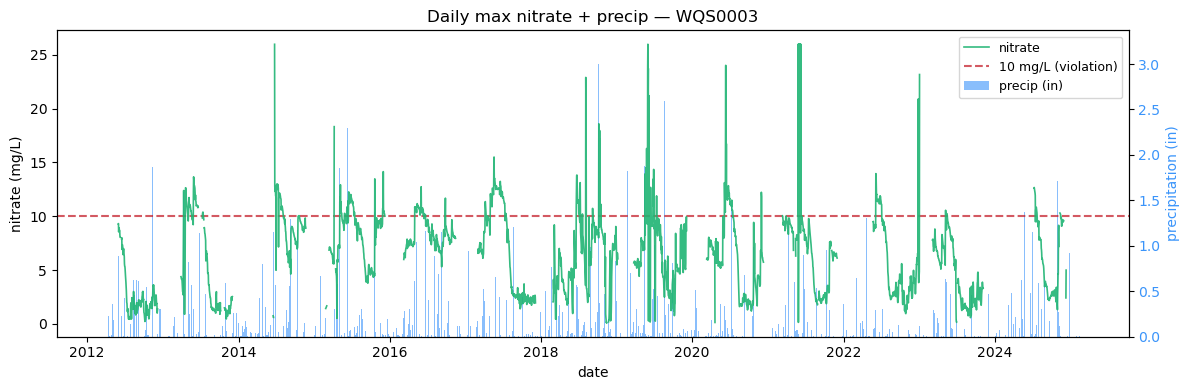

In [9]:
# make a plot of the rain and nitrate timeseries at a site
%matplotlib inline
from demo_eda import *
test_site = "WQS0013" # a medium sized site with good data and a long life
sites = demo_sites()                # modelling pool (≥1500 daily observations)

# plot nitrate timeseries
# lifespan and data gaps are visible
plot_nitrate_timeseries("WQS0003")  # raw signal + violation line

(<Figure size 750x720 with 1 Axes>,
 <Axes: title={'center': 'What drains to WQS0013: cells by dominant crop (2017)'}>)

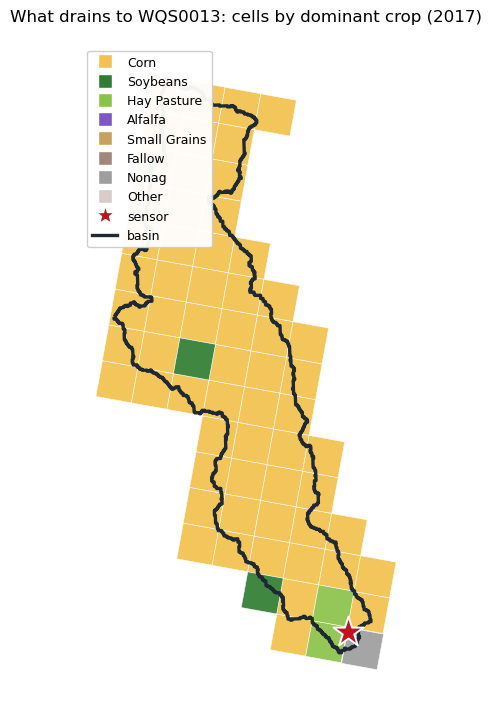

In [ ]:
# an example plot of the basin + rain grid + dominant crop in each cell
# the widget provides a better view than this
# swap this for the 5 site ids printed out by the last cell to see a few examples
plot_basin_crops("WQS0013")         # what's upstream, cells by dominant crop

## Sample of EDA

Here is a sample of the EDA that was performed. The code is found in `eda_demo.py` in this directory. The following is a small demonstration of the seasonality in 

(<Figure size 1100x400 with 1 Axes>,
 <Axes: title={'center': 'Fleet seasonality (day-of-year climatology, all sites)'}, xlabel='day of year', ylabel='mean max nitrate (mg/L)'>)

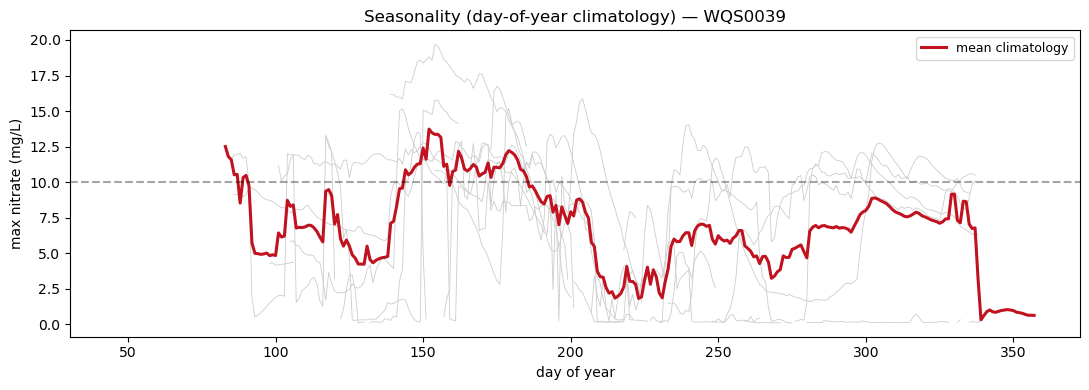

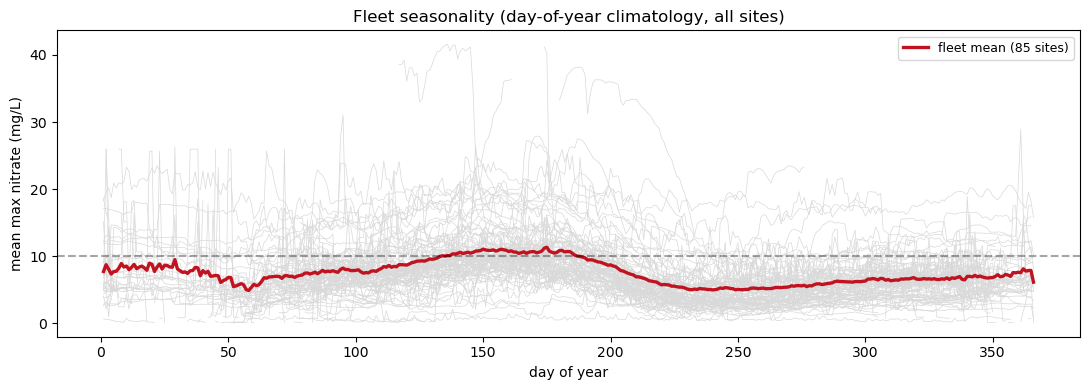

In [2]:
"""
This cell plots the Day of Year climatology of a single site and then of all sites together.
"""

from demo_eda import *
test_site = "WQS0013" # a medium sized site with good data and a long life
plot_seasonality("WQS0039")         # DOY climatology for one site
plot_fleet_seasonality()            # DOY climatology for all sites at once

(<Figure size 1200x1000 with 2 Axes>,
 array([<Axes: title={'center': 'Avg # Violation Days Every Site'}, xlabel='month', ylabel='avg # violation days'>,
        <Axes: title={'center': 'Avg # Days with Violation by Month Across All Sites'}, xlabel='month', ylabel='avg # violation days'>],
       dtype=object))

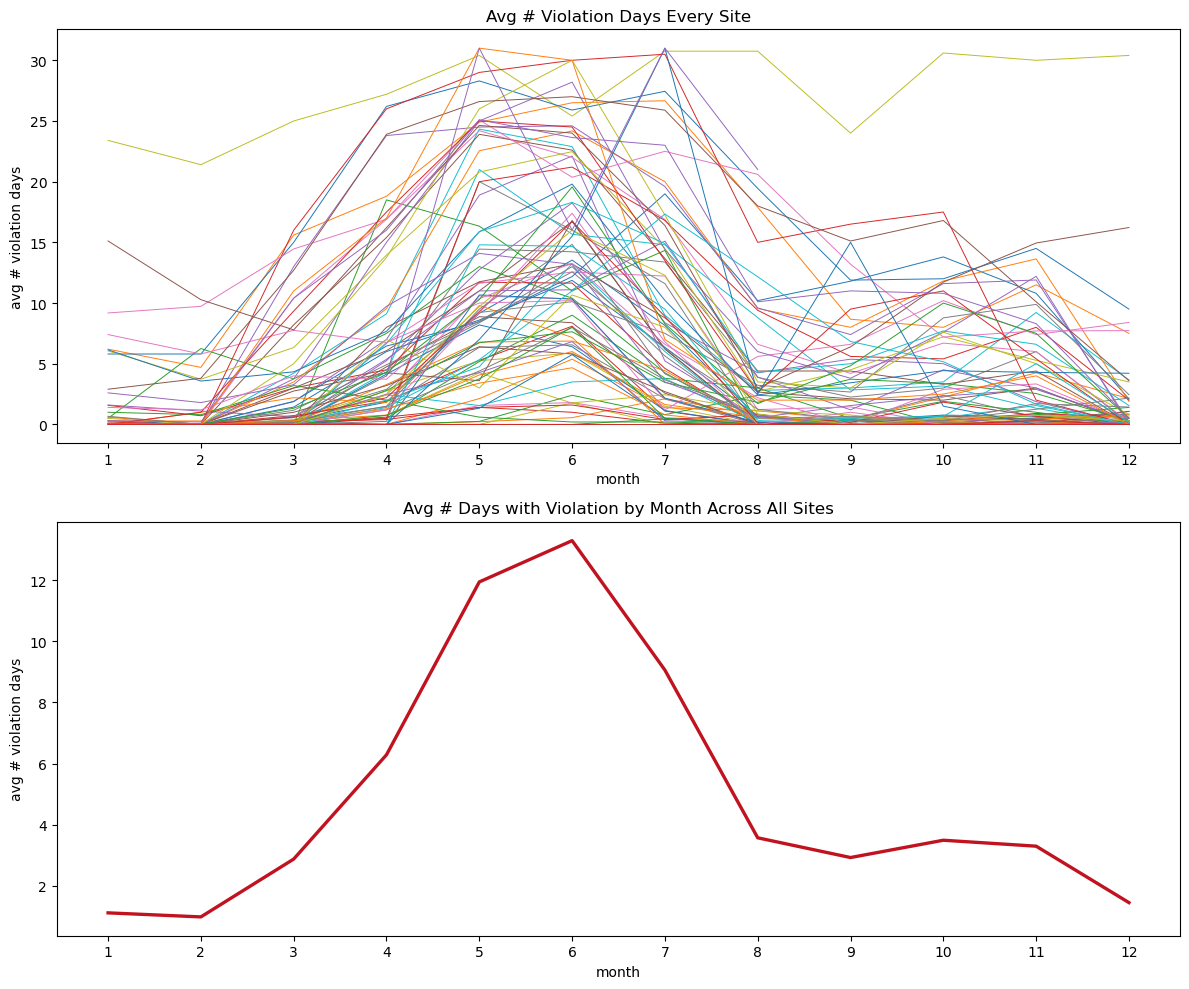

In [3]:
"""
Perhaps more usefully, this cell prints the average number of "violation days" per month for every site and then the average across all sites.

It demonstrates a clear seasonal peak.
"""

plot_violation_days_by_month()

We get a similar seasonality for rainfall. I cannot find the code originally used to produce these graphs and am too lazy to reproduce it right now, but here they are:

<p align = center>
<img src = 'images/rainfall_seasonal_site.png' width = 800></img>
</p>

<p align = center>
<img src = 'images/rainfall_seasonal_all.png' width = 800></img>
</p>

This begs the question: if you control for the seasonality of rainfall, does this account for the seasonality of nitrate violation days/nitrate concentration? We performed an F-test to see.

### F-Test

First all sites are collapsed into one average year, producing a single 365 day timeseries where each point is the average nitrate/violation-rate/rainfall for that calendar day averaged across the whole state. It then fits two regressions on those points:

* H0: after accounting for rainfall, nitrate/violations have NO remaining seasonal structure. The model here is `nitrate ~ precipitation`
* HA: significant seasonal structure remains. The model here is `nitrate ~ precip + sin1 + cos1 + sin2 + cos2`. These additional terms are sin and cos tuned to a period of one year + the first harmonics (so period = 1/2).

Four F-Tests are performed, 2 each for both the regression and the classification tasks. The two F-Tests are "standard F-test" and then the "HAC F-Test". HAC stands for Heteroskedasticity and Autocorrelation Consistent, so the latter F-Test is more honest when the residuals are correlated (which they are for high autocorrelation). The Durbin-Watson test ranges from 0 to 4, ≈ 2 means no autocorrelation, close to 0 means strong positive autocorrelation, close to 4 means strong negative autocorrelation. We report the DW test too (it's close to 0 for both regression and classification targets) to illustrate that the targets are highly autocorrelated via a rigorous statistical test rather than relying on graph-gazing alone.

The cell takes about 90 seconds to run (on a Macbook Air M2).


  F-TEST RESULTS  |  Response: nitrate_con
  n observations    : 365 DOY points
  R2 (rainfall only): 0.3331
  R2 (+ seasonal)   : 0.9672   (+0.6341)
  Durbin-Watson     : 0.112  -> HAC-robust F-test <- use this (autocorrelation present)
  Standard   F = 1732.460,  p = 0.0000
  HAC-robust F = 325.323,  p = 0.0000
  => REJECT H0: seasonal structure remains after rainfall.

  F-TEST RESULTS  |  Response: violation_logit
  n observations    : 365 DOY points
  R2 (rainfall only): 0.3141
  R2 (+ seasonal)   : 0.9364   (+0.6223)
  Durbin-Watson     : 0.165  -> HAC-robust F-test <- use this (autocorrelation present)
  Standard   F = 878.441,  p = 0.0000
  HAC-robust F = 153.441,  p = 0.0000
  => REJECT H0: seasonal structure remains after rainfall.


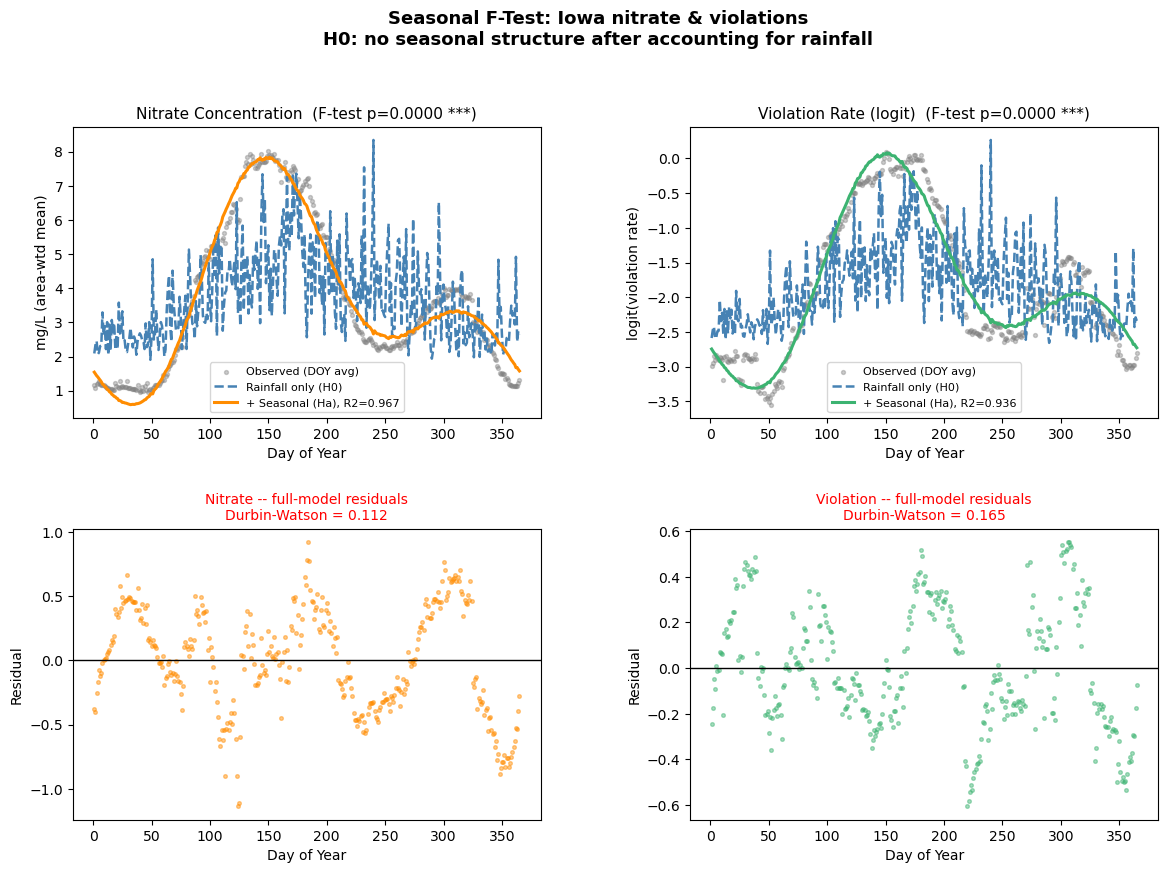

In [10]:
from demo_seasonality_ftest import plot_ftest

# this test demonstrates that seasonality still exists even after controlling
# for rain. This means that seaonality of water borne nitrate is NOT simply caused
# by the seasonality of weather.
plot_ftest()

The jump in $R^2$ from H0 to HA is one piece of evidence to reject H0. An $R^2$ score of 0.97 here shouldn't be too surprising -- a linear combination of the first two Fourier modes pretty well approximates the roughly smooth DOY all sites average -- but the jump is compelling. The p values for both F-tests demonstrate that the F-test is statistically significant: we resoundingly reject the H0 hypotehsis.

So the seasonality of nitrate definitely persists after controlling for rain. We kept this in mind as we moved toward modeling and it influenced our feature engineering, we included lagged rainfall features, pure sin/cos signals with periods matched to one calendar year, and a "seasonal nitrate at all sites other than this one" feature ("other than this one" to prevent data leakage, we can't let a site see its own nitrate record since there IS NO RECORD at a virtual site).

### Autocorrelation and site heterogeneity

The next cell plots the autocorrelation of a specified site. In our original EDA we made a massive plot of all these graphs across all sites, they all look approximately the same. You can convince yourself of this by varying the site id parameter passed to the `plot_autocorrelation` method.

The cell after that shows two different axes of the heterogeneity between sites. Basins vary wildly in size (this is quickly apparent by playing around with the widget) and also possess a variety of class imbalances.

Both of these make cross-site generalization more difficult. For the classification problem in particular, the range of yes/no violation ratios exhibited by the various sites means that it's difficult to tune a model to the class imbalances of all sites simultaneously. However, since one by definition cannot tune to a virtual site using its violation record, accepting a global tuning is necessary.

(<Figure size 900x400 with 1 Axes>,
 <Axes: title={'center': 'Autocorrelation: nitrate vs rain — WQS0013'}, xlabel='lag (days)', ylabel='autocorrelation'>)

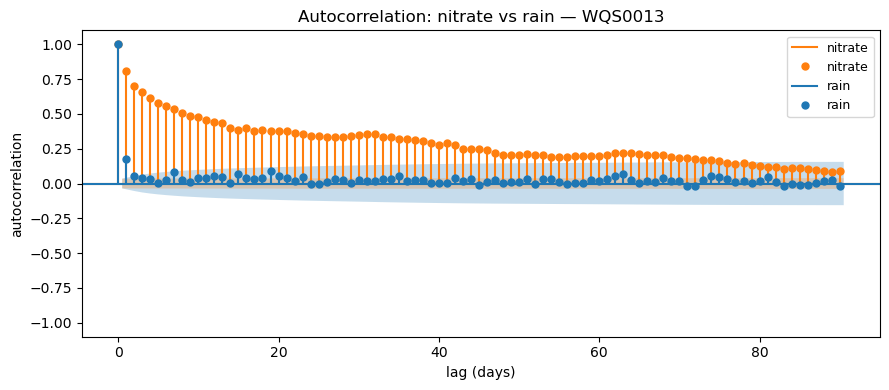

In [ ]:
# uncomment the following three lines if you want more site ids to play with
# from src.data.access import get_site_ids
# ids = get_site_ids()
# print(ids)

# slow decay for nitrate, i.e. "predict yesterday" baseline is strong
plot_autocorrelation("WQS0013")

(<Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'Per-site violation rate (85 sites) — class balance'}, xlabel='fraction of days ≥ 10 mg/L', ylabel='# sites'>)

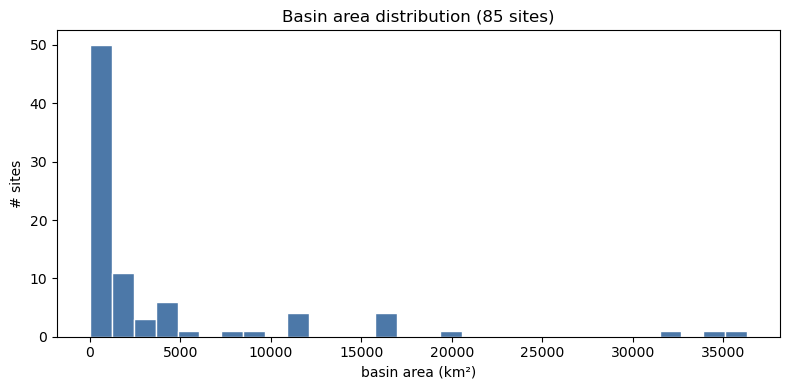

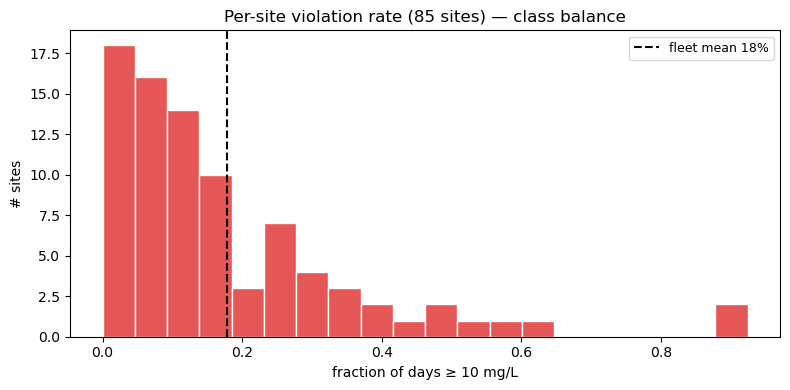

In [5]:
# show basin area distribution and the classification class imbalance between sites
plot_basin_size_distribution()
plot_violation_balance()

One final illustration of the class imbalance: a figure displaying the distribution of average nitrate concentrations across the sites, generated in Preet's `EDA_and_modeling.ipynb`:

<p align = center>
<img src = 'images/avg_nitrate_con_dist.png' width = 800></img>
</p>

## Baselines

Here we illustrate some of the baseline models we looked at. After Preet ran the initial XGBoost test and got pretty good results, we settled on XGBoost and didn't look back (after conferring with out mentor).

The executive summary: standard timeseries modeling for the regression task is quite garbage unless you include a record of a site's past nitrate as a feature, which is cheating unless you're predicting the nitrate concentration at a sensor site, which in turn is useless.

A particularly nice feature of XGBoost in our case is its NaN tolerance and the fact that the order of timesamples doesn't matter. The former factor is important since our land-use surplus data only cover up through 2017, so later years are NaN for that feature. The latter factor is important because our water-borne nitrate timeseries are plagued with NaN values (sensors get turned off in winter, malfunction, etc) but XGBoost doesn't care that we throw those rows away.

### Timeseries forecasting with exponential smoothing

This attempts to forecast the future timeseries using only the past record. It uses Holt-Winters exponential smoothing, reports MSE.

It doesn't do horribly but it isn't a meaningful baseline for our virtual sensor application, again because virtual sites have no history.

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'Holt-Winters monthly forecast — WQS0039  (test MSE=26.910)'}, xlabel='date', ylabel='max nitrate (mg/L)'>)

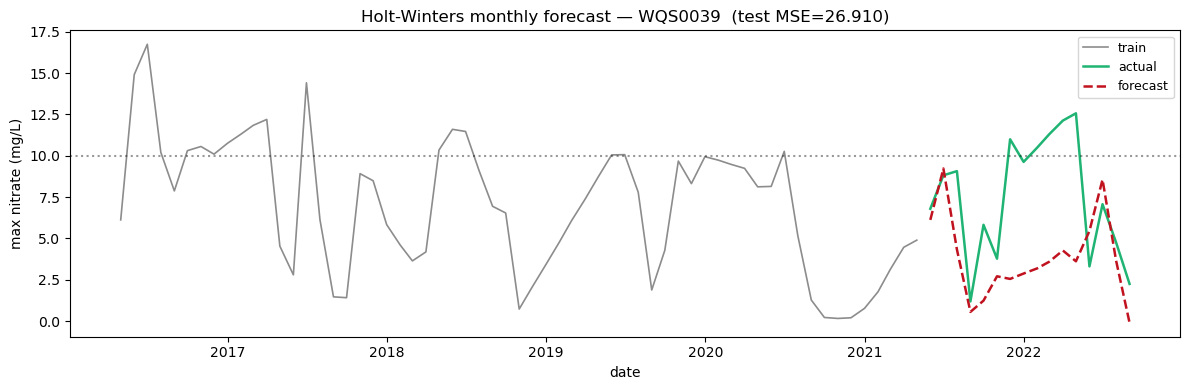

In [ ]:
from demo_baselines import plot_exponential_smoothing
plot_exponential_smoothing("WQS0039")    # experiment by Jay

### Another mix of baselines for regression and classification tasks
This next cell runs 6 baseline models across the classification and regression tasks.

Classification (scored with Average Precision / PR-AUC):

1. `dummy_most_frequent` — always predicts the majority class.
2. `dummy_stratified` — predicts randomly in proportion to the class frequencies, ignores features.
3. `gaussian_rw` — Gaussian random-walk: P(tomorrow > 10 | today) under N(today, σ²), σ from training diffs; uses today's nitrate, not the feature matrix.
4. `logreg` — LogisticRegression(class_weight="balanced") on the scaled features; feature-dependent.

Regression (scored by MAE / RMSE in mg/L):

5. `persistence` — predicts today's value for tomorrow. Uses today's nitrate, not the feature matrix.
6. `linreg` — LinearRegression on the scaled features.

Below we run the baselines both with and without historical nitrate features. It's a little hard to see what changes between the runs, so here is a table of the changes observed for site "WQS0013".
| metric | with nitrate | without nitrate |
|---|---|---|
| logreg_AP | 0.4191 | 0.2322 |
| linreg_MAE | 0.7678 | 151.39 |
| linreg_RMSE | 1.1818 | 169.36 |

It demonstrates in another way that virtual site forecasting is much harder than "real site forecasting".

In [21]:
from demo_baselines import erin_site_df, erin_baselines

site = "WQS0013"

# this is the feature recipe the baseline runs on
df = erin_site_df(site)
print(df.columns)
feature_cols = ['precip_in_1d',
       'rain_x_surplus', 'rain_7d', 'rain_x_surplus_7d', 'rain_14d',
       'rain_x_surplus_14d', 'rain_30d', 'rain_x_surplus_30d', 'year', 'Corn',
       'Soybeans', 'Hay_Pasture', 'Alfalfa', 'Small_Grains', 'Fallow', 'Nonag',
       'Other', 'surplus_n_2017', 'basin_area']

# run the baslines with some lagged nitrate features, then again with none
print(f"{"=" * 40}\n=== With Nitrate Features\n{"=" * 40}")
erin_baselines(site)
print(f"\n{"=" * 40}\n=== WithOUT Nitrate Features\n{"=" * 40}")
erin_baselines(site, feature_cols=feature_cols)

Index(['date', 'nitrate_con', 'nitrate_max', 'violation', 'precip_in_1d',
       'rain_x_surplus', 'rain_7d', 'rain_x_surplus_7d', 'rain_14d',
       'rain_x_surplus_14d', 'rain_30d', 'rain_x_surplus_30d', 'year', 'Corn',
       'Soybeans', 'Hay_Pasture', 'Alfalfa', 'Small_Grains', 'Fallow', 'Nonag',
       'Other', 'surplus_n_2017', 'site_id', 'basin_area', 'nitrate_lag1',
       'nitrate_lag2', 'nitrate_lag3', 'nitrate_tomorrow',
       'violation_tomorrow'],
      dtype='str')
=== With Nitrate Features
Fold 0: train=1038  test=100  test_violations=8
Fold 1: train=1138  test=100  test_violations=18
Fold 2: train=1238  test=100  test_violations=2
Fold 3: train=1338  test=100  test_violations=30
Fold 4: train=1438  test=100  test_violations=0

=== Cross-validated results (mean +/- std across folds) ===

-- Classification (Average Precision / PR-AUC, higher is better) --
dummy_most_frequent_AP        : 0.1160 +/- 0.1113
dummy_stratified_AP           : 0.1134 +/- 0.1109
gaussian_rw_class

,mean,std
dummy_most_frequent_AP,0.116000,0.111283
dummy_stratified_AP,0.113363,0.110926
gaussian_rw_classifier_AP,0.332867,0.327300
logreg_AP,0.232225,0.201930
persistence_regression_MAE,0.636001,0.220589
persistence_regression_RMSE,1.168898,0.348992
linreg_MAE,151.393784,295.799153
linreg_RMSE,169.358744,330.647560


### Regression model comparisons on a single site

The following compares 6 different baseline model types for the regression target. The results are all quite weak, including Gradient Boosting and Random Forest models. Reasons for this:

* a single site doesn't have much data
* features include only rainfall, crops and surplus.

This informed our decision to spend time on feature engineering and to drop an early idea to try and model individual sites in isolation (could have been useful since most sites have been retired).

In [26]:
from demo_baselines import regression_model_comparison

site = "WQS0013"
regression_model_comparison(site) # regression model comparison by Jay

,model,cv_r2_mean,cv_r2_std,test_r2,test_rmse
0,Dummy (mean),-0.043051,0.042876,-0.000986,1.805314
1,Lasso,-0.039181,0.037624,-0.000986,1.805314
2,Ridge,-0.019393,0.081711,-0.198871,1.975718
3,Linear Regression,-0.020238,0.082605,-0.200271,1.976871
4,Gradient Boosting,-0.120848,0.239267,-1.016990,2.562657
5,Random Forest,-0.020637,0.167117,-1.600800,2.909995


### Basic XGBoost explore

This is XGBoost run on "train quickly" hyperparameters and a basic feature list (what we call a "recipe") including only weather, land-use and static data (like latitutde and longitude) -- no engineered features. This is a faithful recreation of Preet's original experiment but constructed using the feature/training pipeline we created. The original notebook is `experiments/preet/EDA_and_modeling.ipynb`. The following should run on 46 of the 85 sites, throwing away those with less than 1500 days of data to speed up the run a bit.

A key finding in Preet's initial XGBoost experiment was this: crops, weather and nitrogen surplus in the sensor's immediate viscinity matters far more than data in the outer reaches of the basin. This is encouraging and makes physical sense, since nitrate in water has a relatively short half life. More on this in the subsequent feature engineering section of the notebook.

It demonstrates a good baseline for XGBoost performance, the highest r^2 values we've seen yet (for sensible feature lists).

In [2]:
from demo_model import plot_feature_importance, plot_pr_curves, run_cv, preet_xgb_baseline
from demo_recipes import recipe_A_static, preet_recipe
from demo_eda import demo_sites

min_rows = 1500

#cv = run_cv(recipe_A_static, min_rows=min_rows, task="clf")   # -> cv.attrs["importance"]["preet_recipe"]

importance = preet_xgb_baseline(sites=demo_sites())
#plot_feature_importance(cv, n=20)
#plot_pr_curves(recipe=recipe_A_static)

  cooked preet_eda_reg: 46/46 sites usable (min_rows >= 500)                    
Fold 1 (Testing on 9 unseen sites) -> Test RMSE: 5.4596, Test R²: 0.0001
Fold 2 (Testing on 9 unseen sites) -> Test RMSE: 5.2511, Test R²: -0.0246
Fold 3 (Testing on 10 unseen sites) -> Test RMSE: 5.2583, Test R²: 0.2781
Fold 4 (Testing on 9 unseen sites) -> Test RMSE: 4.0372, Test R²: 0.2441
Fold 5 (Testing on 9 unseen sites) -> Test RMSE: 4.3213, Test R²: 0.2478

Global Feature Importances:
 Nonag             0.171708
Corn              0.101382
log_basin_area    0.098035
Hay_Pasture       0.079604
total_kg_N        0.078808
Alfalfa           0.076984
Other             0.074953
surplus_kgha      0.072878
Soybeans          0.066862
Small_Grains      0.047823
Fallow            0.044560
rain_roll_30d     0.042652
rain_roll_14d     0.016622
rain_roll_3d      0.012466
rain_roll_7d      0.008930
precip_in_1d      0.005733
month             0.000000
day_of_year       0.000000
week              0.000000


At the conclusion of this EDA, we settled on the final research question above named in the introduction. There is one caveat to this: we briefly entertained the idea of producing specific site models, but quickly moved away from this entirely. This explains the existence of site-specific modeling functions in our `eval` module (`cook/cook_one`, `cook/compare_one`, `cook/compare_fleet`).

## Feature Engineering

The goal of this phase: identify the best possible feature set for our XGBoost models. This phase is proceeded in parallel with the development of our modeling and evaluating (CV) modules.

### Experiments Explanation

Having settled on a research question and XGBoost as our model architecture, we set out trying to identify the best possible feature set we could derive from our model. The full code for this lives in `experiments/isaac/` (Preet performed feature engineering independently by iteratively improving her recipes, but the results of intermediate tests were not saved). After a few ad-hoc experiments, the process was formalized somewhat in `experiments/isaac/experiment/`. Each experiment number identifies a specific question and then has two files, an `_experiment{num}.py` file for the regression target and an `_experiment{num}c.py` file for the classification target. The two-file system was later realized to be stupid and from experiment 13 onwards they were combined. A rudimentary orchestrator `_runexps.py` was written.

Each experiment script produced 2-3 artifacts:

* `_experiment{num}.csv`: various CV scores gathered during the experiment, the main file
* `_experiment{num}_importance.csv`: the XGBoost feature importance scores
* `_experiment{num}_importance_perm.csv`: an optional additional feature importance metric using sklearn's "shuffle/permute a feature column, retrain, see how much worse the results are" importance scorer.

These csvs were written to `experiments/isaac/experiments/test_results/`. The contents of these records were handled in the notebook `experiments/isaac/eating.ipynb` to produce markdown tables which were then manually copy and pasted into report documents located in `experiments/isaac/notes/`. This was also a stupid idea, and it would have been far better for each experiment script to simply generate human-readable experiment summaries.

As a result of this design choice, it is entirely possible but irritatingly slow to parse through the raw results of these experiments. Each experiment, its methodology, and its results are summarized below, time permitting before the project deadline, the relevant experiment tables will be included as well.

### Terminology

* `general-location model`: the virtual site model with either a classification or a regression target
* `site-specific model`: an under-developed idea for modeling a specific sensor site
* `loso`: "Leave One Site Out". This uses holdout strategies which ignore inter-basin leakage.
* `lofo`: "Leave One Family Out". This uses holdout strategies ensuring no data leakage occurs by keeping overlapping basins on the same side of the train/test split.


### Experiment 6/6c — Does lagging weather data improve the model? 
- **Question:** On the general-location model, does adding daily weather beat a no-weather baseline of basin-aggregated crop, surplus, and seasonality?
- **Key features analyzed:** `no_weather` vs `0_Lags` (+ daily weather) vs `1_Lags`–`4_Lags` (progressively adding lagged weather copies).
- **Results:** Weather helps a lot for regression (`0_Lags` loso_r2 0.116 vs `no_weather` 0.003) and modestly for classification (`0_Lags` loso_auc 0.756 vs 0.731). Adding lagged copies does not help and mostly hurts (2_Lags loso_r2 collapses to 0.019); the only lag-driven curiosity is `fuel_moisture_1000h` appearing important.

### Experiment 7/7c — Which recipes win for individual-site (gauged) modeling?
- **Question:** With one model per site, which feature recipe predicts a site's own nitrate best?
- **Key features analyzed:** `A_static` (covariates only), `B_static` (A + site's OWN past nitrate), `C_static` (A + leaky cross-site climatology), `D_static` (A + leakage-protected cross-site nitrate).
- **Results:** Own past nitrate dominates: `B_static` median_r2 0.878 / median_auc 0.978, far above A (median_r2 −0.025 / auc 0.782). Leaky `C` (0.562 / 0.937) beats leakage-safe `D` (0.455 / 0.875), but neither approaches B — and B's own-nitrate features aren't usable for a virtual (ungauged) site.

### Experiment 8/8c — Is nitrogen surplus actually useful for the cross-site model?
- **Question:** Preet's EDA showed surplus had little utiltiy, but that was on pre-2018 data. Does surplus + and static geography help the general-location model on data cut off at 2017-12-31?
- **Key features analyzed:** `A`/`A_static` (covariates ± static lat/lon/basin-area/distance) and `D`/`D_static` (+ leakage-safe cross-site nitrate ± static).
- **Results:** Static features help hugely (`D_static` loso_r2 0.381 vs `D` 0.151; loso_auc 0.820 vs 0.772); longitude and max-distance-to-sensor are strong, especially for classification. Surplus does contribute (top ~12–15) but is secondary; rolling cross-site nitrate is the overpowered feature, it was included in this experiment unrealistically.

### Experiment 9/9c — Which strategy best accounts for cell distance from sensor?
- **Setup:** Preet found that data far from the sensor matters less than data close to the sensor. To account for this Preet and Isaac used different strategies.
  
    - Preet: Collapse data across grid cells into a single aggregate value for each date entry. Aggregate by weighted average, averaging by an exponential decay term $\exp(- \text{dist to sensor} / \lambda)$ with a tunable paramaeter $\lambda$.

    - Isaac: Aggregate values into "distance buckets", regions defined by distance-to-sensor cutoffs.

- **Question:** Are discrete distance buckets (aggregated within bucket using exponential decay weighted average) ever better than a single exp-decay-weighted whole-basin aggregation, across bucket-edge / water-velocity / lambda choices?
- **Method:** Build different models and compare cross validation scores.
- **Key features analyzed:** exp-decay recipes `A_exp_lam{2k,5k,10k,20k}` vs bucket recipes `B_buck_{5k,10k,5k-15k}_v{0.3,0.8}` (1 vs 2 inner edges, two velocities).
- **Results:** 2 buckets > exp-decay-alone > 3 buckets. Best regression is `B_buck_10k_v0.8` (loso_r2 0.273) vs best exp-decay `A_exp_lam10k` (0.131); 3-bucket collapses to ~0.03. This means **TWO DISTANCE GROUPS IS OPTIMAL**. We used only one bucket edge in all recipes going forward. Classification is nearly flat (loso_auc ~0.83–0.85), it doesn't seem to care which strategy is used. `fuel_moisture_1000h_b1` again surprisingly important; total + surplus nitrate show up in shuffle scores, motivating exp 12.

### Experiment 10/10c — Grid search over bucket edge × water velocity × lambda
- **Question:** Follow up from Experiment 9, what're the optimal "geometric hyperparameters", i.e. bucket edge, weather travel-time velocity, and crop/surplus decay length — for each task?
- **Method**: Grid search
- **Key features analyzed:** 27-recipe grid: edge ∈ {5k, 15k, 50k} m, vel ∈ {0.3, 1.2, 2.1} m/s, lam ∈ {2k, 20k, 100k} m.
- **Results:** Regression peaks at `e50k_v2.1_l100k` (lofo_r2 0.175, loso_r2 0.320); classification peaks at `e5k_v2.1_l20k` (lofo_auc 0.827). These per-task geometries became the shipped regularization (edge=50k) and classification (edge=5k) settings.

### Experiment 11/11c — Do rolling precipitation and water-balance features help?
- **Question:** Does adding rolling precip (to account for ambient soil moistness perhaps) and precip−PET water-balance features improve the model?
- **Key features analyzed:** `base` vs `precip` (+precip_roll 30/60d) vs `wbal` (+wbal_roll) vs `both`, at a throwaway geometry on the 20-site pool.
- **Results:** No — they make it worse. Regression `base` lofo_r2 0.013 vs `both` 0.003 / `precip` −0.013; classification `base` loso_auc 0.810 vs `precip` 0.805. Verdict: don't include (later revisited in exp 17).

### Experiment 12/12c — Does broadcasting 2017 surplus forward into 2018–2025 help?
- **Question:** Surplus data stops at 2017. Does copying 2017 values forward through 2025 improve the models vs stopping at 2017 or dropping surplus entirely?
- **Method:** Build three models with different surplus feature columns.
- **Key features analyzed:** `none_surplus` vs `surplus_stop2017` vs `surplus_extended` (2017 copied forward).
- **Results:** Broadcasting hurts. Regression: `surplus_stop2017` lofo_r2 0.013 beats `surplus_extended` −0.166 and `none_surplus` −0.152; classification stop2017 loso_auc 0.810 > extended 0.786. Freezing surplus at a stale value is worse than cutting it off. This may be a quirk of XGBoost now that I'm revisiting this, I believe it ignores mode values. This experiment might be worth rerunning with slightly perturbed broadcasted surplus values from 2017.

### Experiment 13/13c — Do weekly rolling targets model better than window=1 daily?
- **Question:** Does smoothing the target over a rolling window (3D/7D) beat the raw daily (window=1) target?
- **Key features analyzed:** `target_{reg,clf}_w={1,3,7}D_obs={1,3,7}` window × min-obs grid.
- **Results:** No — window=1 daily wins: regression `w=1D` loso_r2 0.304 vs `w=7D` ~0.17; classification `w=1D` loso_auc 0.868 / lofo_auc 0.829, best in the sweep. window=1 kept as the shipped target.

### Experiment 14/14c — Do "spike" (anomaly-from-baseline) targets model better cross-site?
Here we considered a new target, we think it'd still be interesting to build a model for detecting nitrogen "spikes" but we didn't have the time. Interesting even at a site with history because spikes are precisely what the "predict yesterday" baseline can't do.
- **Question:** Does a site-relative spike target — standardized deviation z(t) from a trailing rolling mean (and its binary threshold) — beat absolute level / violation, cross-site?
- **Method:** 
- **Key features analyzed:** REG anomaly z with baseline window N ∈ {7,14,21,30}d; CLF binary spike over N × threshold k ∈ {1.5,2.0,2.5}.
- **Results:** Weak cross-site. Regression lofo_r2 ~0 (best ≈ −0.0006 at N=7D); classification tops out at loso_auc ~0.77 (N=30D, k=1.5), below the level/violation ~0.83. Spikes need a per-site baseline, so cross-site can't support them.

### Experiment 15/15c — Does dropping the group-2 basin family help?
Due to experiment 9 we were using 2 distance buckets. We wondered if dropping the far data entirely improved the model, effectively shrinking large basins to the area immediatley surrounding the sensor.
- **Question:** Does removing the large group-2 basin family from the cross-site pool improve generalization (all_sites vs non-group2)?
- **Key features analyzed:** shipped default recipe (window=1) run on three pools — all_sites, group_2 only, non-group2.
- **Results:** Barely moves. Regression all_sites loso_r2 0.399 vs non-group2 0.390; classification all_sites loso_auc 0.838 vs 0.843 (lofo_auc 0.806 vs 0.781). Group-2-only scores fine (auc 0.830) but has n_families=1 so lofo is NaN. Basically goes to show that the group 2 data doesn't affect much at all. Since it didn't seem to matter it might have been better to drop group2 by default to speed up training, but it felt weird so we didn't.

### Experiment 16/16c — Gauged-site spike modeling with own-history autoregression
- **Question:** Does per-site chronological modeling with the site's own past nitrate rescue the spike target, and is the cross-site optimum N=30 still best per-site?
- **Key features analyzed:** `spike_AR` (+ own past nitrate) vs transfer-safe `spike`, swept over N ∈ {21,30,45,60,90}d, per-site (compare_fleet).
- **Results:** Autoregression clearly helps and larger N is better: regression `spike_AR_reg_N=90` median_r2 0.140 vs non-AR 0.041; classification `spike_AR_clf_N=60` median_auc 0.800 vs non-AR 0.642. Still modest, and AR features are gauged-site-only (not usable for a virtual sensor).

These last 3 experiments were vibecoded while I was away to speak at a conference some time after the initial feature engineering push. They were mostly for re-orienting and ensuring that the shipped feature sets were indeed the correct ones, and that the codebase (dramatically refactored to meet Erdos repo structure specifications) was still operating correctly.

### Experiment 17/17c — Antecedent-moisture integrators + rain interactions on the SHIPPED recipe
- **Question:** Re-running exp 11 against the actual shipped per-task recipe post-refactor, do rolling precip / water balance / rain×surplus interactions help — motivated by Preet's finding that rain_roll_30d dominates?
- **Key features analyzed:** `base` (shipped) vs `roll_precip` (+precip_roll 7/14/30d) vs `wbal` (+wbal 30/60d) vs `roll+interact` (+leaching_risk rain/ET and rain×surplus).
- **Results:** Regression is a wash (base lofo_r2 0.257 vs roll_precip 0.249). Classification `roll_precip` gives a small real lift on the positive class — lofo_prauc 0.639 vs base 0.621 (~+0.017) — while interactions add nothing. This justified adding the antecedent-rain block to the shipped CLF recipe.

### Experiment 18/18c — Finer INNER riparian bucket (0–2 km zone)
- **Question:** Does adding a fine 0–2 km inner boundary (the riparian buffer Preet flagged as dominant) beat the shipped single coarse inner bucket?
- **Key features analyzed:** `single` (shipped edges) vs `riparian` (edges=[2k, EDGE]) vs `multiscale` (edges=[2k,10k,EDGE], reg only).
- **Results:** Big classification win: `riparian` lofo_prauc 0.660 vs single 0.621 (+0.039), lofo_auc 0.811 vs 0.803, brier 0.151→0.146. Regression does NOT benefit (riparian lofo_r2 0.246 vs single 0.257; `multiscale` overfits to 0.165). Ships for CLF only.

### Experiment 19c — Do the two CLF wins stack?
- **Question:** Do the exp-17 antecedent-precip lift and the exp-18 riparian-bucket lift add together rather than overlap, before combining into the new recipe_CLF?
- **Key features analyzed:** `base` vs `riparian` (edges=[2k,5k]) vs `roll_precip` (+precip 7/14/30d) vs `combined` (both).
- **Results:** They stack roughly additively — `combined` lofo_prauc 0.664 vs base 0.621 (≈ base + riparian +0.039 + a touch of precip); lofo_auc 0.812, best of all arms. Confirmed the combined riparian + rolling-precip geometry as the shipped recipe_CLF.

**Summary:** 
Exp 9 demonstrated that distance buckets are still useful even when using weighted average by exponential decay on distance from the sensor.

The grid search (exp 10) set the geometry hyperparameters at edge=50k/vel=2.1/lam=100k for regression and at edge=5k/vel=2.1/lam=20k for classification.

Exp 13 locked the target as the raw window=1 daily value (rolling targets never beat "predict yesterday").

The final refactored experiments(17-19) changed recipe_CLF specifically to include 3 buckets instead of 2. Exp 18's 0–2 km riparian inner bucket (+0.039 lofo_prauc) and exp 17's antecedent rolling-precip block (~+0.017 lofo_prauc) were both adopted, and exp 19 confirmed they stack. recipe_REG kept the single 50k geometry with only its 7d roll-nitrate feature — the riparian bucket, rolling precip, and rain×surplus interactions all failed to help regression, so none were added there.

### Final feature list:


#### Classification model (target = `violation`, 68 features)

**Buckets:** `_b0` = 0–2 km (riparian), `_b1` = 2–5 km, `_b2` = >5 km. Weather buckets are shifted back by their water travel-time lag; crops/surplus are exp-decay weighted (λ=20 km) within each bucket.

- **Weather** per bucket (`_b0/_b1/_b2`), each bucket lagged by travel time (rain from further bucket arrives at sensor later than rain from nearer bucket):
  - `precip_in_1d_b{0,1,2}`: daily precipitation (in)
  - `max_temp_b{0,1,2}`, `min_temp_b{0,1,2}`: daily max / min air temperature
  - `max_rel_humidity_b{0,1,2}`, `min_rel_humidity_b{0,1,2}`: daily max / min relative humidity
  - `vpd_b{0,1,2}`: vapor-pressure deficit (evaporative demand)
  - `solar_rad_b{0,1,2}`: solar radiation
  - `evapotranspiration_b{0,1,2}`: reference ET
  - `fuel_moisture_1000h_b{0,1,2}`: 1000-hr dead-fuel moisture; a slow (~6-week) wetness integrator. Intended as a fire-hazard indicator by the weather people, surprisingly useful here.
- **Crops**: annual CDL area within each bucket, distance-decay weighted (`_b0/_b1/_b2`):
  - `Corn_b{0,1,2}`, `Soybeans_b{0,1,2}`, `Alfalfa_b{0,1,2}`, `Hay_Pasture_b{0,1,2}`, `Small_Grains_b{0,1,2}`, `Fallow_b{0,1,2}`, `Nonag_b{0,1,2}`, `Other_b{0,1,2}`: fraction/area of each land-cover class near the sensor
- **Nitrogen surplus**: annual, per bucket (`_b0/_b1/_b2`):
  - `surplus_kgha_b{0,1,2}`: N surplus per hectare
  - `total_kg_N_b{0,1,2}`: total N surplus mass
- **Calendar** (leakage-free, dates only):
  - `doy_sin`, `doy_cos`: sin/cos of day-of-year (the annual seasonal cycle)
- **Cross-site nitrate** (rest-of-state, this site excluded: usable for a virtual sensor):
  - `rest_of_state_nitrate_lag1`, `_lag2`, `_lag3`, `_lag5`: mean nitrate across all *other* sites, lagged 1/2/3/5 days
- **Static site descriptors:**
  - `lat`, `lon`: sensor coordinates
  - `log_basin_area`: log of drainage-basin area
  - `mean_dist_to_sensor`, `max_dist_to_sensor`: mean / max flow distance from basin cells to the sensor

#### Regression model (target = `nitrate_con`, 50 features)

**Buckets:** `_b0` = 0–50 km, `_b1` = >50 km (coarser single-edge geometry: the riparian bucket didn't help regression). Crops/surplus exp-decay weighted (λ=100 km); weather travel-time lagged.

- **Weather**: daily gridMET, per bucket (`_b0/_b1`), travel-time lagged:
  - `precip_in_1d_b{0,1}`: daily precipitation (in)
  - `max_temp_b{0,1}`, `min_temp_b{0,1}`: daily max / min air temperature
  - `max_rel_humidity_b{0,1}`, `min_rel_humidity_b{0,1}`: daily max / min relative humidity
  - `vpd_b{0,1}`: vapor-pressure deficit
  - `solar_rad_b{0,1}`: solar radiation
  - `evapotranspiration_b{0,1}`: reference ET
  - `fuel_moisture_1000h_b{0,1}`: 1000-hr dead-fuel moisture; a fire hazard indication. Surprisingly useful as reported by both XGBoost importance scores and by sklearn's shuffle.
- **Crops**: annual CDL area per bucket, distance-decay weighted (`_b0/_b1`):
  - `Corn_b{0,1}`, `Soybeans_b{0,1}`, `Alfalfa_b{0,1}`, `Hay_Pasture_b{0,1}`, `Small_Grains_b{0,1}`, `Fallow_b{0,1}`, `Nonag_b{0,1}`, `Other_b{0,1}`
- **Nitrogen surplus**: annual, per bucket (`_b0/_b1`):
  - `surplus_kgha_b{0,1}`: N surplus per hectare
  - `total_kg_N_b{0,1}`: total N surplus mass
- **Calendar:**
  - `doy_sin`, `doy_cos`: sin/cos of day-of-year
- **Cross-site nitrate** (rest-of-state, this site excluded):
  - `rest_of_state_nitrate_lag1`, `_lag2`, `_lag3`, `_lag5`: mean nitrate across all *other* sites, lagged 1/2/3/5 days
  - `roll_n_avg_except_this7d`: 7-day rolling mean of rest-of-state nitrate (REG-only; helps the level target, hurt CLF)
- **Static site descriptors:**
  - `lat`, `lon`: sensor coordinates
  - `log_basin_area`: log of drainage-basin area
  - `mean_dist_to_sensor`, `max_dist_to_sensor`: mean / max flow distance from basin cells to the sensor

  ### Feature Importance
  The feature importance csvs were fascinating in early experiments and then boring in later experiments because they kept saying the same thing. We'll discuss feature importance in the following section for our final models.

## Cross Validation on the final recipe and training

Our feature construction, full dataset creation, train/test split, train, evaluate pipeline looks like this.

- `src.features.recipes`: various predefined recipes defined using features found in `src.features.features`. Each recipe takes a single site id as input and produces the feature DataFrame. The shipped recipes are `recipe_CLF` and `recipe_REG`.
- `src.split.conflict_graph`: this is for train/test splits. If two sites have overlapping basins AND reported data on the same date, you get some amount of data leakage. It builds the "conflict graph", a graph recording which sites overlap both spatially and temporally and providing methods for splitting sites to ensure in-family sites remain on the same side of the test/train split.
- `src.eval.cook`: the main api for training, scoring, evaluating. Here are highlights.
    - `src.eval.cook._pool`: takes a recipe and a list of sites and produces the master full training dataframe
    - `src.eval.cook._grouped_models`: takes a separated feature `X` and target `y` dataframe along with a dictionary mapping site_uids to group ids (either just the site_uids themselves or conflict_graph_ids) and yields the folds for a CV run.
    - `src.eval.cook.compare_many`: the public api CV method. It runs two different test/train splits for the two different kinds of holdouts, one which ignore the inter-site basins leakage (LOSO, Leave One Site Out) and one which respects the conflict graph (LOFO, Leave One Family Out). It then scores on the holdouts using all the metrics we could think of and returns the score DataFrame.

Here's an illustration of the CV scores produced for the classification recipe we settled on. It takes a while to run, so I've copy/pasted the score table here.

In [4]:
import sys
sys.path.insert(0, "../")
from demo_eda import demo_sites
from src.eval.cook import compare_many
from src.models.train import REAL_XGB_REG, REAL_XGB_CLF # configs for xgb
from src.features.recipes import recipe_CLF

# compile the feature + target DataFrame for one example site and
# print its columns to illustrate
example_site = "WQS0013"
df = recipe_CLF(example_site)
print(df.columns, "\n")

def cv(name, recipe, target_col, task, xgb):
    scores = compare_many(
        {name: recipe}, sites=demo_sites(), target_col=target_col, task=task, extra_importance_test=True, min_rows=min_rows, **xgb
    )
    print(scores.round(3).to_string())
 
cv("recipe_CLF", recipe_CLF, target_col="violation", task="clf", xgb=REAL_XGB_REG)

Index(['date', 'violation', 'precip_in_1d_b1', 'precip_in_1d_b2',
       'max_temp_b1', 'max_temp_b2', 'min_temp_b1', 'min_temp_b2',
       'max_rel_humidity_b1', 'max_rel_humidity_b2', 'min_rel_humidity_b1',
       'min_rel_humidity_b2', 'vpd_b1', 'vpd_b2', 'solar_rad_b1',
       'solar_rad_b2', 'evapotranspiration_b1', 'evapotranspiration_b2',
       'fuel_moisture_1000h_b1', 'fuel_moisture_1000h_b2', 'doy_sin',
       'doy_cos', 'rest_of_state_nitrate_lag1', 'rest_of_state_nitrate_lag2',
       'rest_of_state_nitrate_lag3', 'rest_of_state_nitrate_lag5',
       'Alfalfa_b1', 'Alfalfa_b2', 'Corn_b1', 'Corn_b2', 'Fallow_b1',
       'Fallow_b2', 'Hay_Pasture_b1', 'Hay_Pasture_b2', 'Nonag_b1', 'Nonag_b2',
       'Other_b1', 'Other_b2', 'Small_Grains_b1', 'Small_Grains_b2',
       'Soybeans_b1', 'Soybeans_b2', 'total_kg_N_b1', 'total_kg_N_b2',
       'surplus_kgha_b1', 'surplus_kgha_b2', 'lat', 'lon', 'log_basin_area',
       'mean_dist_to_sensor', 'max_dist_to_sensor'],
      dtype='str'

This takes a while to run, here's the copy/pasted score table along with descriptions of the scores.

| metric | value | description |
|---|---|---|
| n_sites | 46 | Number of sites in the pooled dataset (those clearing the min-rows floor) |
| n_families | 13 | Number of basin families (conflict-graph connected components) = number of LOFO holdout groups |
| n_rows | 122760 | Total pooled site-day rows used for training/CV |
| n_feat | 68 | Number of feature columns in the recipe |
| loso_auc | 0.829 | ROC-AUC under Leave-One-Site-Out CV (optimistic: sites from the same family can leak) |
| lofo_auc | 0.809 | ROC-AUC under Leave-One-Family-Out CV (conservative: whole basin family held out → true transfer) |
| loso_prauc | 0.688 | PR-AUC (average precision) under LOSO — the imbalance-aware ranking metric |
| lofo_prauc | 0.662 | PR-AUC under LOFO — the positive-class ranking quality |
| loso_f1 | 0.635 | Best achievable F1 over the threshold sweep, LOSO |
| lofo_f1 | 0.619 | Best achievable F1 over the threshold sweep, LOFO |
| loso_prauc_lift | 2.425 | PR-AUC ÷ base rate, LOSO — how many× better the ranking beats random (>1 = signal) |
| loso_f2 | 0.732 | Best F2 (recall weighted 2× precision), LOSO — favors catching violations |
| loso_mcc | 0.478 | Best Matthews correlation coefficient, LOSO — balanced quality on imbalanced classes (−1..1) |
| loso_recall_at_far | 0.541 | Recall achievable at a false-alarm rate ≤ 10%, LOSO — catch-rate at a fixed alarm budget |
| lofo_prauc_lift | 2.334 | PR-AUC ÷ base rate, LOFO — imbalance-normalized lift |
| lofo_f2 | 0.716 | Best F2, LOFO |
| lofo_mcc | 0.461 | Best Matthews correlation, LOFO |
| lofo_recall_at_far | 0.51 | Recall at false-alarm rate ≤ 10%, LOFO |
| brier | 0.151 | Brier score (mean squared error of predicted probabilities) — calibration, **lower is better** |
| persist_skill | -4.525 | $1 - \frac{\text{MSE}(\text{model})}{\text{MSE}(\text{persistence})}$, performance against "predict yesterday's violation" baseline.|
| base | 0.284 | Base rate — fraction of site-days that are actual violations (the random-guess floor) |
| between_rate_r2 | 0.217 | R² of predicted mean P(violation) vs each site's actual violation rate — does it rank site levels? |
| macro_auc | 0.902 | Median per-site AUC (equal weight per site, vs row-weighted overall) |

### Further discussion of the scores
- Every metric is "higher is better" except for brier, for which lower is better. 
- The "persist_skill" compares the model's performance to the "predict yesterday" baseline, $> 0$ means it beat it. We should expect it to be negative, it's an impossible baseline to beat due to the high autocorrelation of nitrate data at a specific site, and the baseline doesn't make sense at a virtual site anyways.
- Theoretically, we expect that $$\text{lofo performance} < \text{actual performance} < \text{loso performance}$$ meaning that LOSO metrics should be read as best case scenarios and LOFO values as worst case scenarios. In practice, LOSO and LOFO values are almost always quite close, and we think the phenomenon of cross-site data leakage practically doesn't exist. LOFO holdouts are usually much bigger than LOSO holdouts (many conflict families are large) so you end up holding out a lot of data in the LOFO runs. This means the performance of LOSO could be entirely due to the fact that LOSO trains on more data, and not because LOSO actually leaks.

We discuss our interpretation of these numbers more in the results section, where we report on the scores for training across all sites, not just the demo sites.

### Feature Importance

Here are the top features in the final models. There are two different importance metrics used:

- **`gain`** – XGBoost split-gain: how much each feature reduced loss across the splits it was used in.
- **`perm`** – permutation importance: the drop in held-out performance when that column is shuffled.

We interpret these metrics as follows: "gain" measure how much the model leans on a particular feature to make its predictions, "perm" measures how much performance actually drops when you mangle the feature. This means "perm" is a better for measuring whether a feature is helpful in generalization.

The code below reads off from the logs produced by training runs and reports the top 20 features by both scoring methodologies. Set `SORT_BY_PERM` to `False` below to sort by the gain values instead.

In [5]:
# prints the top 20 perm and gain features from the logs/fultrain_logs.json file
import json
from pathlib import Path
import pandas as pd

_LOG = next(
    path / "logs/fulltrain_logs.json"
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "logs/fulltrain_logs.json").exists()
)
_entries = json.load(open(_LOG))

SORT_BY_PERM = True

def _latest(task):
    """Most recent full-train log entry for the task (reg / clf)."""
    hits = [(int(key), val) for key, val in _entries.items() if val.get("task") == task]
    return max(hits)[1]


def combined_importance(task, topn=20):
    """Union of the top-`topn` features by gain and by permutation, sorted by gain (desc).
    Between `topn` and 2*`topn` rows -- always contains the full top-`topn` of BOTH metrics.
    Adds gain_rank / perm_rank: each a 1..num_rows ranking within the displayed rows (1 = most
    important), computed on the raw values so there are no ties or gaps."""
    e = _latest(task)
    gain = pd.Series(e["importance"], name="gain")
    perm = pd.Series(e.get("importance_perm", {}), name="perm")
    df = pd.concat([gain, perm], axis=1)
    keep = df.index.isin(gain.nlargest(topn).index) | df.index.isin(perm.nlargest(topn).index)
    if SORT_BY_PERM:
        out = df[keep].sort_values("perm", ascending=False)
    else: 
        out = df[keep].sort_values("gain", ascending=False)
    out["gain_rank"] = out["gain"].rank(ascending=False, method="first").astype(int)
    out["perm_rank"] = out["perm"].rank(ascending=False, method="first").astype(int)
    out = out.round(4)
    out.index.name = f"{e['name']} — {task}"
    return out[["gain", "gain_rank", "perm", "perm_rank"]]


reg_tbl = combined_importance("reg")
clf_tbl = combined_importance("clf")
print(f"recipe_REG: {len(reg_tbl)} rows (union of top-20 gain & top-20 perm)")
display(reg_tbl)
print(f"recipe_CLF: {len(clf_tbl)} rows (union of top-20 gain & top-20 perm)")
display(clf_tbl)

recipe_REG: 25 rows (union of top-20 gain & top-20 perm)


,gain,gain_rank,perm,perm_rank
recipe_REG2 — reg,,,,
rest_of_state_nitrate_lag1,0.1761,1,0.1443,1
lat,0.0815,3,0.1242,2
Nonag_b0,0.0205,10,0.1041,3
Alfalfa_b0,0.0166,13,0.0566,4
Soybeans_b0,0.0109,21,0.0485,5
roll_n_avg_except_this7d,0.1001,2,0.0474,6
Corn_b0,0.0197,11,0.0439,7
Other_b0,0.0139,18,0.0342,8
Small_Grains_b0,0.0080,23,0.0329,9


recipe_CLF: 26 rows (union of top-20 gain & top-20 perm)


,gain,gain_rank,perm,perm_rank
recipe_CLF2 — clf,,,,
rest_of_state_nitrate_lag1,0.1167,1,0.0642,1
lat,0.0599,3,0.0236,2
lon,0.0476,6,0.0177,3
doy_sin,0.0086,23,0.0140,4
fuel_moisture_1000h_b2,0.0078,25,0.0137,5
mean_dist_to_sensor,0.0564,4,0.0080,6
max_dist_to_sensor,0.0512,5,0.0067,7
rest_of_state_nitrate_lag2,0.0744,2,0.0051,8
doy_cos,0.0086,24,0.0048,9


- `rest_of_state_nitrate_lag1` is the most important feature by both measures, it provides a baseline for the background level of nitrate across the entire state.
- `lat` and `lon` are both pretty vital to the model which makes sense, location is a proxy for geographic variations not accounted for in our data set (proximity to other nitrate pollution sources not in our dataset, for example)
- `fuel_moisture_1000h_b2` is the most perplexing feature. It routinely shows up as a useful feature across all experiments. It's a long-term fire-hazard metric, a measure of the dryness of large fuel like logs over 1000h time lag. It's also strange that the b2 value, i.e. the value corresponding to the outer reaches of the basin, is the one that ranks highest in shuffle importance. Our best guess for the importance of this feature is that it serves as a proxy for the drainability of nitrate in the outer reaches of the basin, where its harder for nitrate to reach the sensor. When the ground is damp for long periods of time, perhaps its more likely that nitrate in the outer reaches of the basin can reach the sensor.
- `doy_sin` and `doy_cos` features provide a reference point for seasonality, which turns out to be useful
- `corn_b2`, `corn_b0`, `Nonag_b2`, etc. The various crop features are all important, and XGBoost uses the ones closer to the sensor more.
- `max_dist_to_sensor` and `mean_dist_to_sensor` are both important static features.
- Surplus nitrate data, `surplus_N` features, don't show up in the top 20 important features. Experiments show its better to include it, but its usefulness is capped because the data only runs up to the last day of 2017 (hopefully the researchers who put it together will write a followup). Because of this, shuffling the column doesn't do much and XGBoost ignores it.

## Results and deployment

To build a model we run `src/models/train.py` from the command line. It uses a cross validation run on all sites to tune the number of iterations XGBoost should run and stores the statistics generated by the CV in a log file, `logs/fulltrain_logs.json` (`python logs/render_logs.py` to produce more readable summaries from the JSON files). It then trains a deployable model on the full dataset (no holdouts) for use in the widget and stores it in `src/models/models/`. It does this for both classification and regression targets, producing two models.

Below we discuss the scores for each of the models, how the honestly perform and what their limitations are.

In [4]:
# get the score table for the specified model
import json
from pathlib import Path
import pandas as pd

# descriptions for the printout
METRIC_DESCRIPTIONS = {
    # dataset shape
    "n_sites": "Number of sites in dataset",
    "n_families": "Number of basin families",
    "n_rows": "Total number of data rows",
    "n_feat": "Number of feature columns",

    # regression
    "loso_r2": "R^2 under LOSO CV (optimistic)",
    "lofo_r2": "R^2 under LOFO CV (conservative)",
    "rmse": "RMSE of predicted nitrate (mg/L, lower is better)",
    "spearman": "Spearman rank correlation of prediction vs actual (scale-free)",
    "between_r2": "R^2 of predicted vs actual per-site MEANS. Measures whether correctly ranks which sites are high/low.",
    "within_r2": "R\u00b2 after removing each site's mean \u2014 tracks day-to-day movement within a site?",
    "macro_r2": "Median per-site R\u00b2 (equal weight per site)",

    # classification task
    "loso_auc": "ROC-AUC under LOSO (optimistic)",
    "lofo_auc": "ROC-AUC under LOFO (honest transfer to unseen basins)",
    "loso_prauc": "PR-AUC (average precision) under LOSO \u2014 imbalance-aware ranking",
    "lofo_prauc": "PR-AUC under LOFO \u2014 honest positive-class ranking quality",
    "loso_f1": "Best F1 over the probability-threshold sweep, LOSO",
    "lofo_f1": "Best F1 over the probability-threshold sweep, LOFO",
    "loso_prauc_lift": "PR-AUC \u00f7 base rate, LOSO (>1 beats a random ranker)",
    "lofo_prauc_lift": "PR-AUC \u00f7 base rate, LOFO (imbalance-normalized lift)",
    "loso_f2": "Best F2 (recall weighted 2x precision), LOSO \u2014 favors catching violations",
    "lofo_f2": "Best F2 (recall weighted 2x precision), LOFO",
    "loso_mcc": "Best Matthews correlation coefficient, LOSO (-1..1)",
    "lofo_mcc": "Best Matthews correlation coefficient, LOFO",
    "loso_recall_at_far": "Recall at false-alarm rate <= the FAR budget (default 10%), LOSO",
    "lofo_recall_at_far": "Recall at false-alarm rate <= the FAR budget (default 10%), LOFO",
    "brier": "Brier score (MSE of predicted probabilities) \u2014 calibration, lower is better",
    "base": "Base rate \u2014 fraction of site-days that are actual violations (random-guess floor)",
    "between_rate_r2": "R\u00b2 of predicted mean P(violation) vs each site's actual violation RATE",
    "macro_auc": "Median per-site AUC (equal weight per site)",
    # shared
    "persist_skill": "Comparison to 'predict yesterday' (1 - MSE_model/MSE_persist; >0 beats it; gauged-only)",
}

# trimmed metric list
_KEEP = [
    # dataset shape (context)
    "n_sites", "n_families", "n_rows", "n_feat",
    # regression
    "loso_r2", "lofo_r2", "rmse", "between_r2", "within_r2", "macro_r2",
    # classification
    "loso_auc", "lofo_auc", "lofo_prauc_lift", "lofo_recall_at_far", "lofo_f2",
    "brier", "base", "between_rate_r2", "macro_auc",
]


def model_scores(name, full=False):
    log_path = next(
        p / "logs/fulltrain_logs.json"
        for p in [Path.cwd(), *Path.cwd().parents]
        if (p / "logs/fulltrain_logs.json").exists()
    )
    entries = json.load(open(log_path))
    hits = [(int(k), v) for k, v in entries.items() if v.get("name") == name]
    if not hits:
        avail = sorted({v.get("name") for v in entries.values()})
        raise KeyError(f"No logged model named {name!r}. Available: {avail}")
    _, entry = max(hits)  # most recent run under this name

    def _fmt(v):
        if isinstance(v, float):
            return int(v) if v.is_integer() else round(v, 4)
        return v

    score = entry["score"]
    keys = list(score) if full else [m for m in _KEEP if m in score]  # trimmed + ordered by default
    s = pd.Series({m: score[m] for m in keys}, dtype=object).map(_fmt)
    df = s.to_frame("value")
    df["description"] = [METRIC_DESCRIPTIONS.get(m, "") for m in df.index]
    df.index.name = f"metric ({name})"
    return df


### Regression model results

In [5]:
model_scores("recipe_REG2")

,value,description
metric (recipe_REG2),,
n_sites,80.0000,Number of sites in dataset
n_families,19.0000,Number of basin families
n_rows,160074.0000,Total number of data rows
n_feat,50.0000,Number of feature columns
loso_r2,0.3800,R^2 under LOSO CV (optimistic)
lofo_r2,0.3280,R^2 under LOFO CV (conservative)
rmse,4.3575,"RMSE of predicted nitrate (mg/L, lower is better)"
between_r2,0.2094,R^2 of predicted vs actual per-site MEANS. Mea...
within_r2,0.4187,R² after removing each site's mean — tracks da...


The regression model predicts the **daily nitrate concentration (mg/L)** at a site. Here's how we read the above table (execute the above cell if you haven't already):

- **`lofo_r2` = 0.33** (`loso_r2` 0.38): is the average $R^2$ training 
- The **decomposition is the real story.** `within_r2` = 0.42 vs `between_r2` = 0.21: the model tracks the *day-to-day movement* of nitrate within a basin roughly twice as well as it ranks *which basins sit high vs low* overall. `spearman` = 0.65 says the ordering of predictions is decent; `macro_r2` = 0.24 is the median per-site fit.
- **`rmse` = 4.4 mg/L** — the typical error is on the order of the 10 mg/L violation threshold itself, so the regressor is a *trend / "shape" estimator*, not a calibrated concentration meter.

In short: the regressor knows **when a basin's nitrate is rising or falling** better than it knows **the absolute level a never-before-seen basin sits at.** That between-site level gap is the model's core limitation, and it is exactly why we also train a classifier — a *ranked* violation probability degrades more gracefully than an absolute mg/L prediction.

### Classification model results

The classifier predicts **P(violation)** — the probability that a day's nitrate exceeds the 10 mg/L EPA limit. This is the model the widget leans on, and the one whose metrics matter most for a *risk-screening* use case.

In [3]:
model_scores("recipe_CLF2")

,value,description
metric (recipe_CLF2),,
n_sites,80.0000,Number of sites in dataset
n_families,19.0000,Number of basin families
n_rows,160074.0000,Total number of data rows
n_feat,68.0000,Number of feature columns
loso_auc,0.8430,ROC-AUC under LOSO (optimistic)
lofo_auc,0.8197,ROC-AUC under LOFO (honest transfer to unseen ...
loso_prauc,0.6841,PR-AUC (average precision) under LOSO — imbala...
lofo_prauc,0.6341,PR-AUC under LOFO — honest positive-class rank...
loso_f1,0.6375,"Best F1 over the probability-threshold sweep, ..."


Reading the classifier table (`recipe_CLF2`, all 80 sites, base rate 26%):

- **`lofo_prauc_lift` = 2.41** is the headline: on unseen basin families the model ranks violation days **~2.4x better than chance** (`lofo_prauc` 0.63 vs a 0.26 base rate). On an imbalanced target this — not raw accuracy or AUC — is the honest "is there real signal" number.
- **`macro_auc` = 0.90 vs `between_rate_r2` = 0.24** — the same split we saw for regression. *Within* a basin the model separates violation days from safe days extremely well (median per-site AUC 0.90); *across* basins it ranks which sites are riskiest overall only weakly. It is a good **timer**, a mediocre **site-ranker**.
- **`lofo_recall_at_far` = 0.52** is the operating point: tuned to a 10% false-alarm budget, the model catches ~52% of real violations. This is the deployment-relevant number, and it is **tunable** — our `recipe_CLF_far_20` (same booster, 20% false-alarm budget) catches **~69%** instead. You trade false alarms for catch-rate depending on how costly a missed violation is (see the tuning discussion / `--false-alarm-rate` flag on `train.py`).
- **`brier` = 0.137** beats the trivial "always predict the base rate" score (0.26 x 0.74 = 0.19), so the probabilities are *meaningfully calibrated*, not merely correctly ordered — which matters because the widget shows P(violation) as a number, not a rank.
- **`persist_skill` = -3.9** — ignore it here (as noted above, "predict yesterday" is an unbeatable, and inapplicable, baseline for an ungauged site).

### What the models can and cannot do

**What they genuinely do well**
- **Virtual site prediction.** The whole point: given only a location, they deliver a daily predicted nitrate concentration and P(violation) timeseries for a basin with *no sensor* — from land use, weather, nitrogen surplus, geography, and the rest-of-state nitrate level. Tuned to 
- **Timing within a basin.** `within_r2` ~ 0.42 and `macro_auc` ~ 0.90 — they reliably indicate *when* a given basin is spiking (the spring / early-summer flush), which is what drives seasonal risk.
- **Ranked, tunable violation risk.** ~2.4x lift over chance, with a false-alarm / recall operating point you can dial to the use case.

**Where they are limited**
- **Absolute site level is soft.** `between_r2` / `between_rate_r2` ~ 0.21-0.24 — they rank *which* basins are chronically worst only weakly. Treat a single site's predicted mg/L as an estimate with real uncertainty (`rmse` ~ 4 mg/L), not a measurement.
- **Not a sensor replacement.** Where a gauge already exists, "predict yesterday" beats the model (negative `persist_skill`); the model earns its keep *only* at ungauged points and does not obviate installing real monitors at high-value sites.
- **Rare-event ceiling.** Violations are ~26% of site-days; at a strict false-alarm budget recall is bounded (52% at 10% FAR). Operating at high recall means accepting more false alarms.
- **Data blind spots.** Nitrogen surplus is frozen at its 2017 values, there are no point-source pollution inputs (`lat`/`lon` only *proxy* for them), and predictions for basins unlike anything in the 80-site fleet (very different geology or land use) are extrapolations and should be trusted less.

### Deployment

`train.py` fits the two deployable boosters (`isaac_REG2.json`, `isaac_CLF2.json`) on **all** rows and stores them in `src/models/models/` (copies live in `deploy/models/` for the widget). The interactive widget is the delivery vehicle:

1. **Drop a pin** anywhere in the region -> `build_virtual_basin` delineates the upstream basin via USGS NLDI.
2. `virtual_recipe` builds the same feature frame the models were trained on for that basin and a chosen year — **no local nitrate history required**.
3. `predict` scores both boosters -> a **daily predicted-nitrate curve** (regression) and a **daily P(violation) curve** (classification) at that ungauged point, plus a peak-probability / days-over summary.

The intended use is **risk screening and monitoring prioritisation** — "where might nitrate be a problem, and roughly when" — to help decide where a real sensor or intervention is most warranted. It is a decision-support layer on top of the sparse gauge network, not a substitute for it.